# Notebook 02: Feature Matrix Definition & Spatial Feature Validation

Defines the 20-feature matrix (Moran's I + local gradient for each of 10 TLS signature
scores) used by both the unsupervised clustering model and the LR baseline.

1. Label distributions — RCC (TLS_2_cat) and KC/LC (ETLS/MTLS/GC) per sample
2. Training spot selection — inclusion/exclusion criteria, GC → MTLS merge
3. Spatial feature discriminability — AUROC/PR on RCC and KC/LC separately
4. Score gradients ETLS → MTLS → GC — biological motivation for the feature choice
5. Feature matrix assembly — z-score per dataset, correlation check, save to disk

In [1]:
import sys
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../')

# ── Load RCC (backed='r': X stays on disk, ~4 GB) ────────────────────────
adata_rcc = sc.read_h5ad('../data/processed/rcc_visium.h5ad', backed='r')
print(f'RCC: {adata_rcc.n_obs} spots × {adata_rcc.n_vars} genes')
print(f'  TLS_2_cat: {dict(adata_rcc.obs["TLS_2_cat"].value_counts(dropna=False))}')

# ── Load KC/LC (obs+obsm only, no expression matrix) ─────────────────────
adata_kclc = sc.read_h5ad('../data/processed/kc_lc_visium.h5ad')
print(f'\nKC/LC: {adata_kclc.n_obs} spots')
print(f'  Samples: {sorted(adata_kclc.obs["sample_id"].unique())}')

# ── Base signature score columns only (exclude _sm / _local_grad / _local_moran) ──
# After preprocess_all.py, obs also contains derived columns that start with 'score_';
# restrict to the 11 base scores by filtering out the spatial-feature suffixes.
_DERIVED = ('_sm', '_local_grad', '_local_moran')
SCORE_COLS = sorted([
    c for c in adata_rcc.obs.columns
    if c.startswith('score_') and not any(c.endswith(s) for s in _DERIVED)
])
print(f'\nSignature scores ({len(SCORE_COLS)}): {SCORE_COLS}')

# ── Spatial feature columns (2 per score: local_moran + local_grad) ───────
SPATIAL_FEAT_COLS = (
    [f'{c}_local_moran' for c in SCORE_COLS] +
    [f'{c}_local_grad'  for c in SCORE_COLS]
)
print(f'Spatial features: {len(SPATIAL_FEAT_COLS)} total '
      f'({len(SCORE_COLS)} scores × 2 stats)')


RCC: 73280 spots × 17943 genes
  TLS_2_cat: {'NO_TLS': 58801, nan: 12057, 'TLS': 2262, 'T_agg': 160}

KC/LC: 19404 spots
  Samples: ['KC1', 'KC3', 'LC1', 'LC2', 'LC3', 'LC5']

Signature scores (11): ['score_b_cell_core', 'score_cxcl13_anchor', 'score_exhaustion', 'score_germinal_center', 'score_hev_markers', 'score_myeloid_sup', 'score_plasma_output', 'score_t_cell_zone', 'score_tfh', 'score_tls_chemokines', 'score_tregs']
Spatial features: 22 total (11 scores × 2 stats)


## 1. Ground Truth Label Distribution

In [2]:
# ── RCC: spot counts by label ─────────────────────────────────────────────
print('=== RCC TLS_2_cat ===')
rcc_counts = adata_rcc.obs['TLS_2_cat'].value_counts(dropna=False)
print(rcc_counts.to_string())

# ── KC/LC: spot counts by label and sample ────────────────────────────────
print('\n=== KC/LC tls_label_fine per sample ===')
kclc_tbl = (adata_kclc.obs
            .groupby(['sample_id', 'tls_label_fine'], observed=True)
            .size().unstack(fill_value=0))
print(kclc_tbl.to_string())


=== RCC TLS_2_cat ===
TLS_2_cat
NO_TLS    58801
NaN       12057
TLS        2262
T_agg       160

=== KC/LC tls_label_fine per sample ===
tls_label_fine  ETLS  GC  INFL  MTLS   NOR   TUM  UNASSIGNED
sample_id                                                   
KC1               42   0    35     0   282  1088        2243
KC3               90   0   129    42   840   440        1113
LC1               53   9   112    76  1646   579        1886
LC2               51   0    30    37   490   514        1813
LC3              184  18    42   142   929   772        1660
LC5               14   0    56    17   223   312        1395


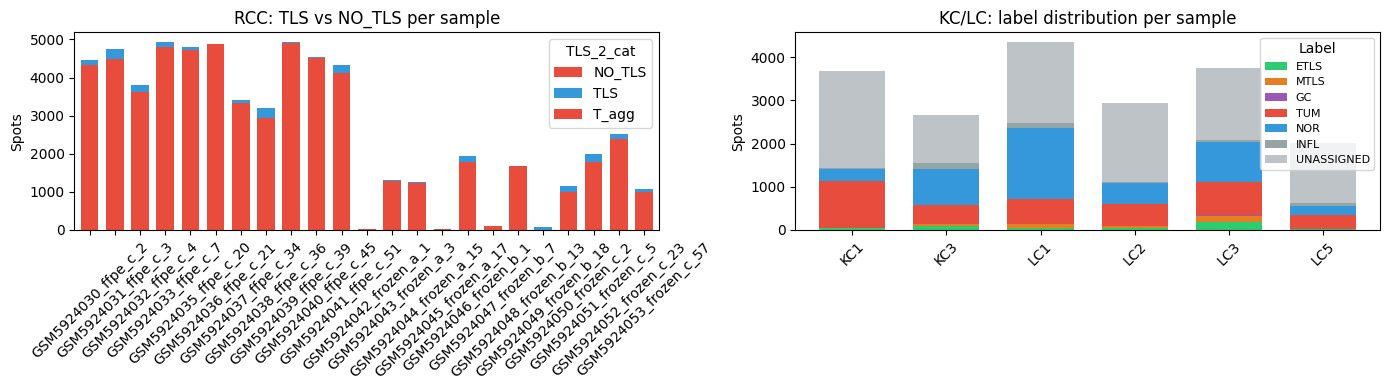

Saved → checkpoints/label_distributions.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── RCC ──────────────────────────────────────────────────────────────────
rcc_labeled = adata_rcc.obs[adata_rcc.obs['TLS_2_cat'].notna()]
rcc_per_sample = (rcc_labeled.groupby(['sample_id', 'TLS_2_cat'], observed=True)
                  .size().unstack(fill_value=0))
rcc_per_sample.plot(kind='bar', stacked=True, ax=axes[0],
                    color=['#e74c3c', '#3498db'], width=0.7)
axes[0].set_title('RCC: TLS vs NO_TLS per sample')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Spots')
axes[0].legend(title='TLS_2_cat', loc='upper right')

# ── KC/LC ─────────────────────────────────────────────────────────────────
label_colors = {
    'ETLS': '#2ecc71', 'MTLS': '#e67e22', 'GC': '#9b59b6',
    'TUM':  '#e74c3c', 'NOR':  '#3498db',
    'INFL': '#95a5a6', 'UNASSIGNED': '#bdc3c7',
}
kclc_per_sample = (adata_kclc.obs
                   .groupby(['sample_id', 'tls_label_fine'], observed=True)
                   .size().unstack(fill_value=0))
col_order = [c for c in label_colors if c in kclc_per_sample.columns]
kclc_per_sample[col_order].plot(kind='bar', stacked=True, ax=axes[1],
                                 color=[label_colors[c] for c in col_order], width=0.7)
axes[1].set_title('KC/LC: label distribution per sample')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Spots')
axes[1].legend(title='Label', loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../checkpoints/label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/label_distributions.png')


## 2. Annotated Spots Preparation

In [4]:
# ── RCC: annotated spots (TLS or NO_TLS, NaN excluded) ───────────────────
obs_rcc = adata_rcc.obs.copy()
obs_rcc_ann = obs_rcc[obs_rcc['TLS_2_cat'].isin(['TLS', 'NO_TLS'])].copy()
obs_rcc_ann['tls_binary'] = (obs_rcc_ann['TLS_2_cat'] == 'TLS').astype(int)
print(f'RCC annotated: {len(obs_rcc_ann)} spots '
      f'({obs_rcc_ann["tls_binary"].sum()} TLS, '
      f'{(~obs_rcc_ann["tls_binary"].astype(bool)).sum()} NO_TLS)')

# Verify spatial features are present (should be after preprocess_all.py)
missing = [f for f in SPATIAL_FEAT_COLS if f not in obs_rcc.columns]
if missing:
    raise RuntimeError(
        f'{len(missing)} spatial features missing from rcc_visium.h5ad. '
        'Re-run: python scripts/preprocess_all.py'
    )
print(f'Spatial features confirmed: {len(SPATIAL_FEAT_COLS)} columns present')

# ── KC/LC: evaluation-eligible spots ─────────────────────────────────────
# GC → MTLS (only 27 GC spots, too sparse for a separate class)
# INFL + UNASSIGNED excluded (ambiguous ground truth)
# TUM + NOR form the non-TLS reference class
obs_kclc = adata_kclc.obs.copy()
obs_kclc['label_eval'] = obs_kclc['tls_label_fine'].copy()
obs_kclc.loc[obs_kclc['label_eval'] == 'GC', 'label_eval'] = 'MTLS'
exclude_labels = {'INFL', 'UNASSIGNED'}
obs_kclc_eval = obs_kclc[~obs_kclc['label_eval'].isin(exclude_labels)].copy()
obs_kclc_eval['tls_binary'] = obs_kclc_eval['label_eval'].isin(['ETLS', 'MTLS']).astype(int)

print(f'\nKC/LC eval-eligible: {len(obs_kclc_eval)} spots')
print(obs_kclc_eval['label_eval'].value_counts().to_string())
print(f'\nBinary: {obs_kclc_eval["tls_binary"].sum()} TLS-positive, '
      f'{(~obs_kclc_eval["tls_binary"].astype(bool)).sum()} TLS-negative')


RCC annotated: 61063 spots (2262 TLS, 58801 NO_TLS)
Spatial features confirmed: 22 columns present

KC/LC eval-eligible: 8890 spots
label_eval
NOR           4410
TUM           3705
ETLS           434
MTLS           341
GC               0
INFL             0
UNASSIGNED       0

Binary: 775 TLS-positive, 8115 TLS-negative


## 3. Spatial Feature Discriminability (vs RCC TLS_2_cat)

Evaluate each spatial feature (`_local_moran`, `_local_grad`) against RCC TLS\_2\_cat pseudo-labels.  
Purpose: identify signatures with near-zero discriminability before committing to the 16-feature matrix.

Features are evaluated on annotated RCC spots only (2,262 TLS / ~58,801 NO\_TLS).  
Raw signature scores are **not** evaluated here — they are excluded from the feature matrix
(circular via pseudo-labels; see PLAN.md fairness constraint).


In [5]:
from sklearn.metrics import roc_auc_score, average_precision_score

y = obs_rcc_ann['tls_binary'].values

rows = []
for col in SCORE_COLS:
    for stat in ('_local_moran', '_local_grad'):
        feat = f'{col}{stat}'
        if feat not in obs_rcc_ann.columns:
            continue
        vals = obs_rcc_ann[feat].fillna(0).values
        try:
            auroc = roc_auc_score(y, vals)
            auprc = average_precision_score(y, vals)
        except Exception:
            auroc, auprc = np.nan, np.nan
        rows.append({'feature': feat,
                     'score': col.replace('score_', ''),
                     'stat': stat.lstrip('_'),
                     'AUROC': round(auroc, 4),
                     'AUPRC': round(auprc, 4)})

roc_df = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
print(roc_df.to_string(index=False))

# Signatures with AUROC < 0.55 in BOTH stats are candidates for exclusion
low_count = roc_df[roc_df['AUROC'] < 0.55].groupby('score')['AUROC'].count()
low_both  = low_count[low_count == 2].index.tolist()
print(f'\nSignatures with AUROC < 0.55 in both stats: {low_both if low_both else "none"}')
print('These will be excluded from the feature matrix in Section 6.')


                          feature           score        stat  AUROC  AUPRC
    score_b_cell_core_local_moran     b_cell_core local_moran 0.7913 0.3635
  score_plasma_output_local_moran   plasma_output local_moran 0.7709 0.1782
 score_tls_chemokines_local_moran  tls_chemokines local_moran 0.7628 0.2588
    score_t_cell_zone_local_moran     t_cell_zone local_moran 0.7058 0.2611
            score_tfh_local_moran             tfh local_moran 0.5982 0.1102
  score_cxcl13_anchor_local_moran   cxcl13_anchor local_moran 0.5917 0.1008
          score_tregs_local_moran           tregs local_moran 0.5899 0.0826
   score_plasma_output_local_grad   plasma_output  local_grad 0.5498 0.0684
     score_exhaustion_local_moran      exhaustion local_moran 0.5454 0.0527
  score_tls_chemokines_local_grad  tls_chemokines  local_grad 0.5449 0.0709
     score_t_cell_zone_local_grad     t_cell_zone  local_grad 0.5413 0.0578
     score_b_cell_core_local_grad     b_cell_core  local_grad 0.5352 0.1093
score_germin

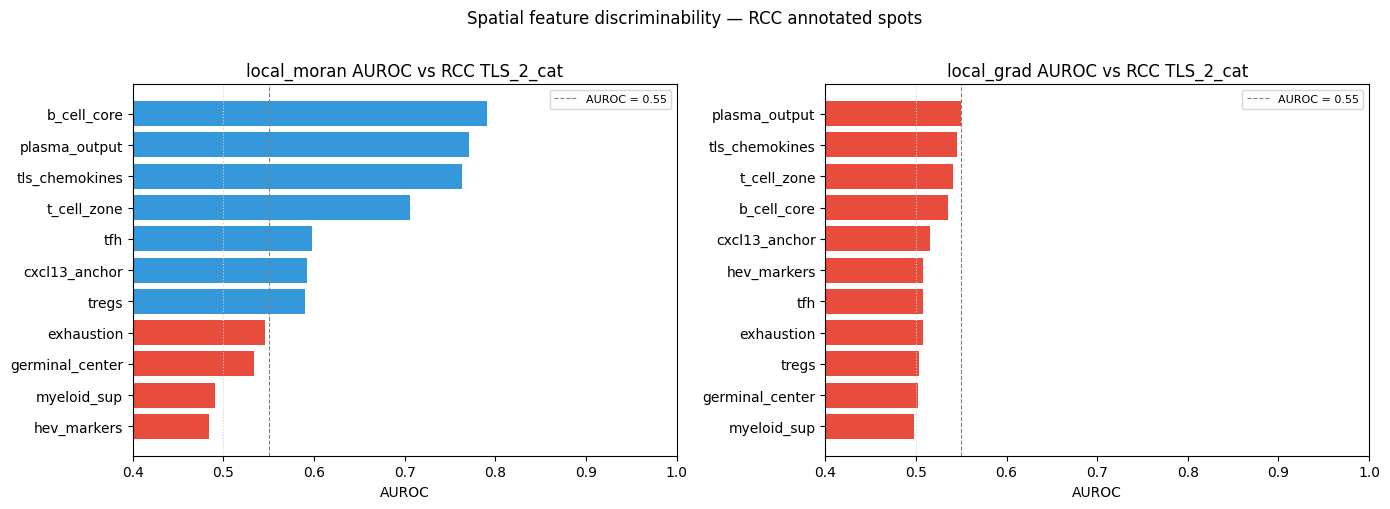

Saved → checkpoints/spatial_feature_auroc.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, stat in zip(axes, ['local_moran', 'local_grad']):
    sub = roc_df[roc_df['stat'] == stat].sort_values('AUROC', ascending=True)
    colors = ['#e74c3c' if v < 0.55 else '#3498db' for v in sub['AUROC']]
    ax.barh(sub['score'], sub['AUROC'], color=colors)
    ax.axvline(0.55, color='gray', linestyle='--', linewidth=0.8, label='AUROC = 0.55')
    ax.axvline(0.50, color='lightgray', linestyle=':', linewidth=0.8)
    ax.set_title(f'{stat} AUROC vs RCC TLS_2_cat')
    ax.set_xlabel('AUROC')
    ax.set_xlim(0.4, 1.0)
    ax.legend(fontsize=8)

plt.suptitle('Spatial feature discriminability — RCC annotated spots', y=1.01)
plt.tight_layout()
plt.savefig('../checkpoints/spatial_feature_auroc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/spatial_feature_auroc.png')


## 4. Per-Sample Summary


In [7]:
# ── RCC per-sample ────────────────────────────────────────────────────────
rcc_rows = []
for sid, grp in obs_rcc.groupby('sample_id', observed=True):
    rcc_rows.append({
        'sample_id': sid,
        'total': len(grp),
        'TLS': (grp['TLS_2_cat'] == 'TLS').sum(),
        'NO_TLS': (grp['TLS_2_cat'] == 'NO_TLS').sum(),
        'unannotated': grp['TLS_2_cat'].isna().sum(),
    })
rcc_sum = pd.DataFrame(rcc_rows)
denom = rcc_sum[['TLS', 'NO_TLS']].sum(axis=1)
rcc_sum['TLS_pct'] = (100 * rcc_sum['TLS'] / denom.replace(0, np.nan)).round(1)
print('=== RCC per-sample ===')
print(rcc_sum.to_string(index=False))

# ── KC/LC per-sample ──────────────────────────────────────────────────────
kclc_rows = []
for sid, grp in obs_kclc.groupby('sample_id', observed=True):
    kclc_rows.append({
        'sample_id': sid,
        'cancer_type': grp['cancer_type'].iloc[0],
        'total': len(grp),
        'ETLS': (grp['label_eval'] == 'ETLS').sum(),
        'MTLS': (grp['label_eval'] == 'MTLS').sum(),
        'GC_orig': (grp['tls_label_fine'] == 'GC').sum(),
        'TUM': (grp['label_eval'] == 'TUM').sum(),
        'NOR': (grp['label_eval'] == 'NOR').sum(),
        'excluded': grp['tls_label_fine'].isin({'INFL', 'UNASSIGNED'}).sum(),
    })
kclc_sum = pd.DataFrame(kclc_rows)
kclc_sum['TLS_pct'] = (100 * (kclc_sum['ETLS'] + kclc_sum['MTLS']) / kclc_sum['total']).round(1)
print('\n=== KC/LC per-sample ===')
print(kclc_sum.to_string(index=False))


=== RCC per-sample ===
             sample_id  total  TLS  NO_TLS  unannotated  TLS_pct
   GSM5924030_ffpe_c_2   4448  124    4324            0      2.8
   GSM5924031_ffpe_c_3   4754  257    4497            0      5.4
   GSM5924032_ffpe_c_4   3829  199    3607           23      5.2
   GSM5924033_ffpe_c_7   4938  128    4810            0      2.6
  GSM5924034_ffpe_c_10   4734    0       0         4734      NaN
  GSM5924035_ffpe_c_20   4799   82    4717            0      1.7
  GSM5924036_ffpe_c_21   4881    0    4881            0      0.0
  GSM5924037_ffpe_c_34   3417   88    3329            0      2.6
  GSM5924038_ffpe_c_36   3205  255    2950            0      8.0
  GSM5924039_ffpe_c_39   4930   16    4914            0      0.3
  GSM5924040_ffpe_c_45   4539   21    4518            0      0.5
  GSM5924041_ffpe_c_51   4324  206    4118            0      4.8
 GSM5924042_frozen_a_1   1450    0       0         1423      NaN
 GSM5924043_frozen_a_3   1439   33    1277          129      2.5
GS

## 5. Score Gradients Across TLS Maturation States (KC/LC)

Box plots of `_local_moran` and `_local_grad` for each signature across ETLS → MTLS → GC maturation states.
This is the biological motivation for the whole spatial-clustering approach: if spatial features track
maturation state, unsupervised clustering on these features should recover ETLS/MTLS structure.

GC spots shown separately (not merged into MTLS) to reveal the full biological gradient.
Only spots with unambiguous labels shown (INFL/UNASSIGNED excluded).


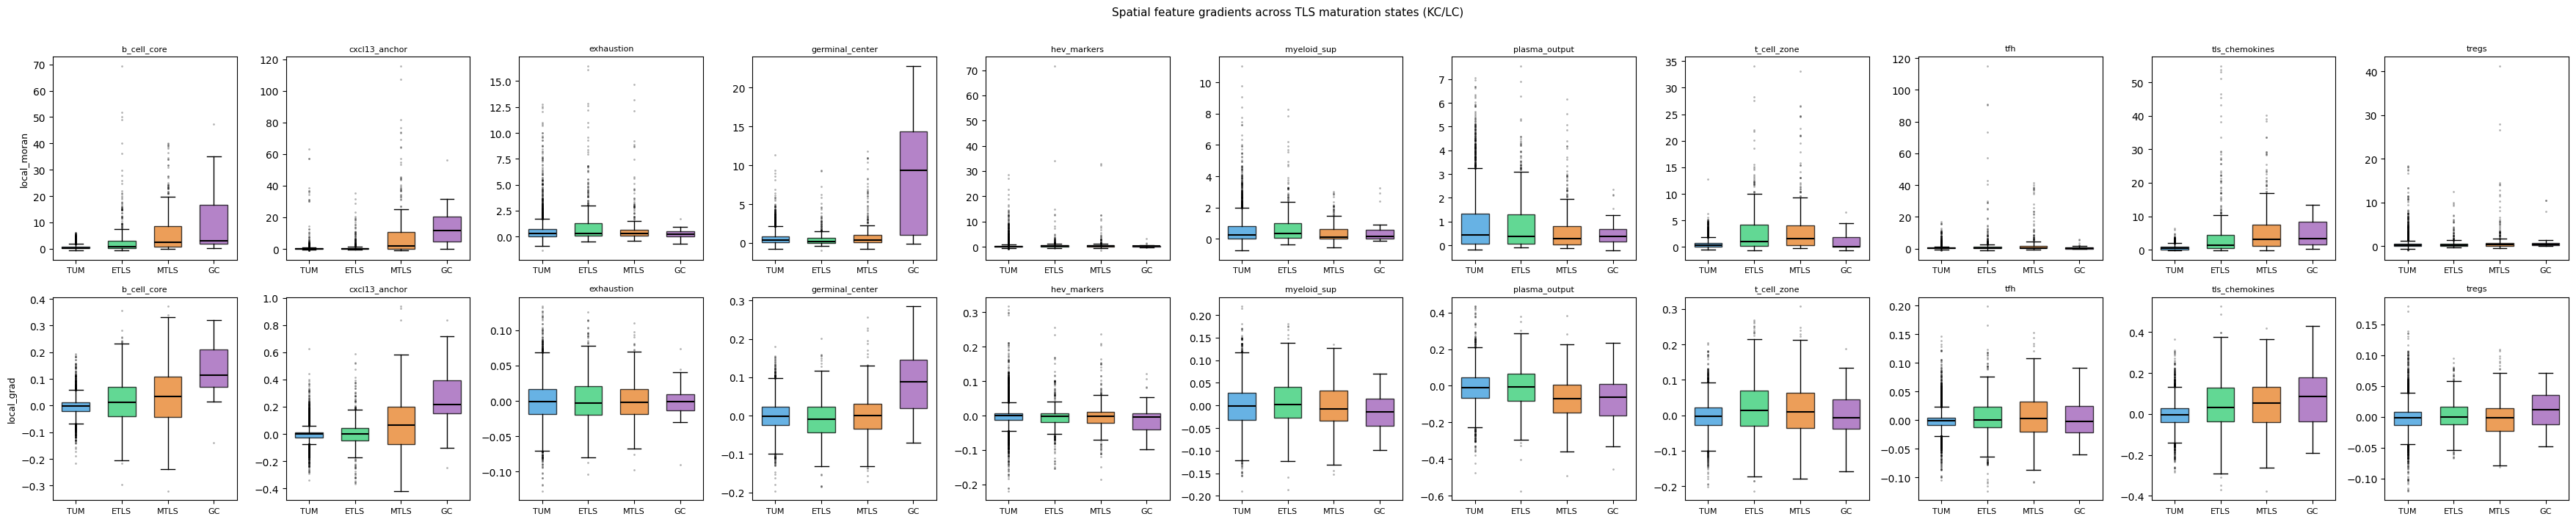

Saved → checkpoints/maturation_gradients.png


In [8]:
# Show TLS maturation gradient: TUM (reference) → ETLS → MTLS → GC
label_order   = ['TUM', 'ETLS', 'MTLS', 'GC']
label_clr_box = {'TUM': '#3498db', 'ETLS': '#2ecc71', 'MTLS': '#e67e22', 'GC': '#9b59b6'}

# Use raw tls_label_fine to keep GC separate here (not merged)
plot_obs = obs_kclc[obs_kclc['tls_label_fine'].isin(label_order)].copy()

n_scores = len(SCORE_COLS)
fig, axes = plt.subplots(2, n_scores, figsize=(3.2 * n_scores, 7))

for col_i, score in enumerate(SCORE_COLS):
    score_name = score.replace('score_', '')
    for row_i, stat in enumerate(['_local_moran', '_local_grad']):
        feat = f'{score}{stat}'
        ax = axes[row_i, col_i]
        if feat not in plot_obs.columns:
            ax.set_visible(False)
            continue
        data_by_lbl = [plot_obs.loc[plot_obs['tls_label_fine'] == lbl, feat].dropna().values
                       for lbl in label_order]
        bp = ax.boxplot(data_by_lbl, patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.5),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3),
                        widths=0.6)
        for patch, lbl in zip(bp['boxes'], label_order):
            patch.set_facecolor(label_clr_box[lbl])
            patch.set_alpha(0.75)
        ax.set_xticks(range(1, len(label_order) + 1))
        ax.set_xticklabels(label_order, fontsize=8)
        ax.set_title(score_name, fontsize=8)
        if col_i == 0:
            ax.set_ylabel(stat.lstrip('_'), fontsize=9)

plt.suptitle('Spatial feature gradients across TLS maturation states (KC/LC)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('../checkpoints/maturation_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/maturation_gradients.png')


## 6. Feature Matrix Assembly & Save

Assembles the final feature matrix (N × K, where K = 2 × kept signatures):
- Any signature with AUROC < 0.55 in **both** stats (Section 3) is dropped
- Per-dataset z-score normalization (mean/std computed independently per dataset)
- Saves to `data/processed/feature_matrix_rcc.npz` and `data/processed/feature_matrix_kclc.npz`

nb03 loads these files directly — no recomputation needed.


Keeping 7/11 signatures: ['b_cell_core', 'cxcl13_anchor', 'plasma_output', 't_cell_zone', 'tfh', 'tls_chemokines', 'tregs']
Feature matrix: 14 features

RCC: 73280 total spots, 61063 annotated
  Z-score range after clip: [-9.81, 10.00]
KC/LC: 19404 total spots, 8890 eval-eligible
  Z-score range after clip: [-6.10, 10.00]


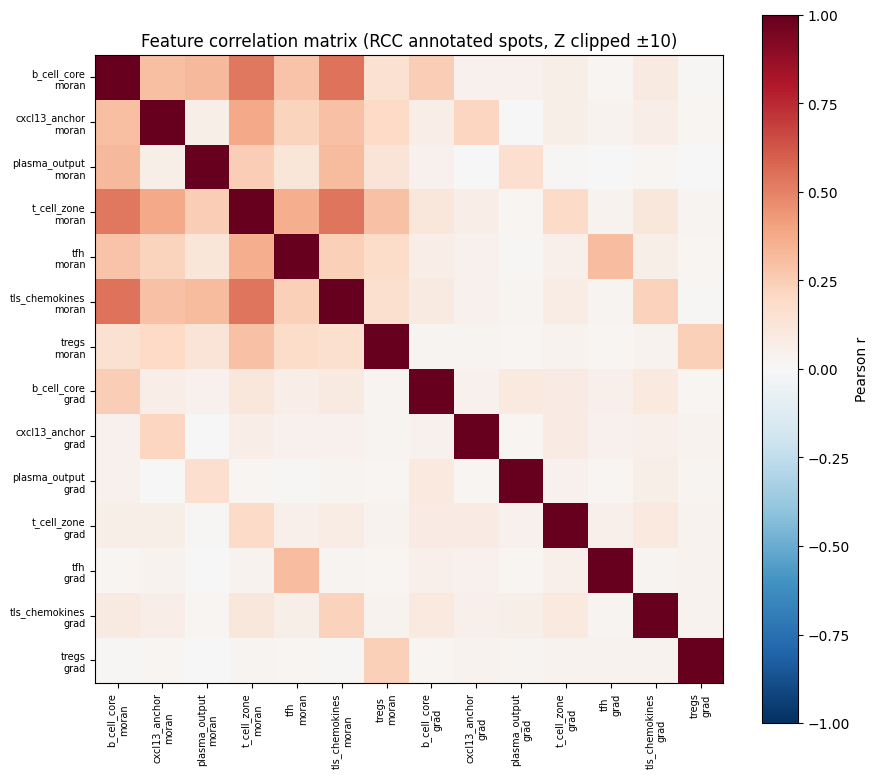

Saved → checkpoints/feature_correlation.png

Saved:
  data/processed/feature_matrix_rcc.npz   — shape (73280, 14)
  data/processed/feature_matrix_kclc.npz  — shape (19404, 14)


In [9]:
import pathlib

# ── Select features (exclude low-discriminability signatures) ─────────────
keep_scores = [c for c in SCORE_COLS if c.replace('score_', '') not in low_both]
print(f'Keeping {len(keep_scores)}/{len(SCORE_COLS)} signatures: '
      f'{[c.replace("score_","") for c in keep_scores]}')

feat_cols = (
    [f'{c}_local_moran' for c in keep_scores] +
    [f'{c}_local_grad'  for c in keep_scores]
)
print(f'Feature matrix: {len(feat_cols)} features')

CLIP = 10.0   # local_moran can be O(z_i × z_j): clip to ±10 before saving

# ── RCC feature matrix ────────────────────────────────────────────────────
X_rcc = obs_rcc[feat_cols].fillna(0).values.astype(np.float32)
mu_rcc  = X_rcc.mean(axis=0)
std_rcc = X_rcc.std(axis=0)
X_rcc_z = np.clip((X_rcc - mu_rcc) / (std_rcc + 1e-8), -CLIP, CLIP)

train_mask_rcc = obs_rcc['TLS_2_cat'].isin(['TLS', 'NO_TLS']).values
y_rcc = (obs_rcc['TLS_2_cat'] == 'TLS').astype(int).values

print(f'\nRCC: {X_rcc_z.shape[0]} total spots, {train_mask_rcc.sum()} annotated')
print(f'  Z-score range after clip: [{X_rcc_z.min():.2f}, {X_rcc_z.max():.2f}]')

# ── KC/LC feature matrix (per-dataset z-score) ────────────────────────────
missing_feats = [f for f in feat_cols if f not in obs_kclc.columns]
if missing_feats:
    print(f'WARNING: {len(missing_feats)} features missing from KC/LC — zero-filled')
    print(f'  Missing: {missing_feats}')
    print('  Fix: re-run scripts/preprocess_kc_lc.py (score_tolerogenic_signatures added)')
X_kclc_cols = []
for f in feat_cols:
    if f in obs_kclc.columns:
        X_kclc_cols.append(obs_kclc[f].fillna(0).values)
    else:
        X_kclc_cols.append(np.zeros(len(obs_kclc), dtype=np.float32))
X_kclc = np.column_stack(X_kclc_cols).astype(np.float32)
mu_kclc  = X_kclc.mean(axis=0)
std_kclc = X_kclc.std(axis=0)
X_kclc_z = np.clip((X_kclc - mu_kclc) / (std_kclc + 1e-8), -CLIP, CLIP)

eval_mask_kclc = ~obs_kclc['tls_label_fine'].isin({'INFL', 'UNASSIGNED'}).values
y_kclc_binary  = obs_kclc_eval['tls_binary'].reindex(obs_kclc.index, fill_value=0).values

print(f'KC/LC: {X_kclc_z.shape[0]} total spots, {eval_mask_kclc.sum()} eval-eligible')
print(f'  Z-score range after clip: [{X_kclc_z.min():.2f}, {X_kclc_z.max():.2f}]')

# ── Correlation matrix (RCC annotated spots) ─────────────────────────────
corr = pd.DataFrame(X_rcc_z[train_mask_rcc], columns=feat_cols).corr()
short_names = [f.replace('score_','').replace('_local_','\n') for f in feat_cols]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_cols))); ax.set_xticklabels(short_names, rotation=90, fontsize=7)
ax.set_yticks(range(len(feat_cols))); ax.set_yticklabels(short_names, fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Feature correlation matrix (RCC annotated spots, Z clipped ±10)')
plt.tight_layout()
plt.savefig('../checkpoints/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/feature_correlation.png')

# ── Save ──────────────────────────────────────────────────────────────────
out_dir = pathlib.Path('../data/processed')
out_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    out_dir / 'feature_matrix_rcc.npz',
    X            = X_rcc_z,
    y            = y_rcc,
    train_mask   = train_mask_rcc,
    feature_names= np.array(feat_cols),
    sample_ids   = obs_rcc['sample_id'].values,
    norm_mean    = mu_rcc,
    norm_std     = std_rcc,
    clip         = np.float32(CLIP),
)
np.savez_compressed(
    out_dir / 'feature_matrix_kclc.npz',
    X            = X_kclc_z,
    y            = y_kclc_binary,
    eval_mask    = eval_mask_kclc,
    feature_names= np.array(feat_cols),
    sample_ids   = obs_kclc['sample_id'].values,
    label_fine   = obs_kclc['tls_label_fine'].values,
    label_eval   = obs_kclc['label_eval'].values,
    norm_mean    = mu_kclc,
    norm_std     = std_kclc,
    clip         = np.float32(CLIP),
)
print('\nSaved:')
print(f'  data/processed/feature_matrix_rcc.npz   — shape {X_rcc_z.shape}')
print(f'  data/processed/feature_matrix_kclc.npz  — shape {X_kclc_z.shape}')



## Next Steps

**nb03** loads `data/processed/feature_matrix_rcc.npz` and `data/processed/feature_matrix_kclc.npz` directly.

Planned workflow:
1. Unsupervised clustering (Leiden / k-means) on combined z-scored feature matrix
2. Post-hoc: map clusters to KC/LC ETLS/MTLS labels (ARI, silhouette, composition plots)
3. Logistic regression on same features + RCC pseudo-labels; evaluate on KC/LC ground truth
4. Head-to-head: unsupervised vs LR on KC/LC (ROC, PR, confusion matrix)
